# Applied Math 10: Computing for Science and Engineering

## Midterm Assignment 

**Fall 2020**<br/>

Handed out: Thursday, Oct. 29, 2020

Due: 11.59 am; Thursday, Nov. 5, 2020

In [2]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline 
from scipy.ndimage.filters import gaussian_filter1d
from scipy.optimize import curve_fit
from scipy import stats

### Instructions

- Use print with some descriptive text to show your answers, for e.g.: 
```
print(f'The average height is {height}')
```
- For floating-point numbers print no more than 3 decimal points.

- **Note:** A useful set of statistical functions are included in the [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) package.

## Problem 1: Mystery Function

1. Import the set of points by loading the following two data files: `AM10_L08_3_x.txt` and `AM10_L08_3_y.txt` in variables $x$ and $y$ respectively.
2. Look up $x$ and $y$ array shape, check if their dimension is the same as it should be.
3. Create a plot of $x$ and $y$ points and describe what you see.
4. Fit an approximate function (fitting function) and plot it using `curve_fit`. [Hint: it is important to choose an appropriate fitting function; check carefully the plot of $x$ and $y$ points, in part 3, in order to identify a proper fitting function.]
5. Calculate the RMSE.


PART 2
The shape of x is: (100,)
The shape of y is: (100,)
Yes, the shape of x and y are the same 

PART 3


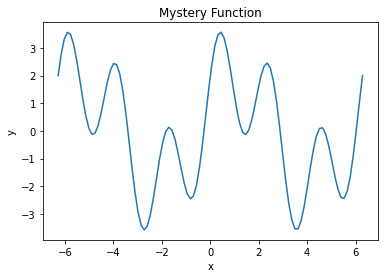

The mystery function is clearly periodic, but it is not a simple sine curve. It appears to be a mutliplication of  two sinusoidal functions, since there is one enveloping periodic function with smaller osciliations embedded in that function.

PART 4 & 5
Number of variables used = 5
RMSE = [9.61848151e-16]


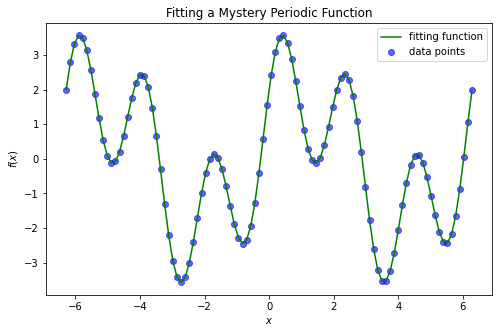

This function could fit slightly better, but with an error this small I will not add any more variables to beware  of overfitting
<class 'numpy.ndarray'>


In [3]:
# load data
x=np.loadtxt("AM10_L08_3_x.txt")
y=np.loadtxt("AM10_L08_3_y.txt")
print('PART 2')
print("The shape of x is:",x.shape) #check shape
print("The shape of y is:",y.shape)
print("Yes, the shape of x and y are the same ")
print()
print('PART 3')
plt.plot(x,y) #plot 
plt.xlabel('x')
plt.ylabel('y')
plt.title('Mystery Function')
plt.show()
print("The mystery function is clearly periodic, but it is not a simple sine curve. It appears to be a mutliplication of  two sinusoidal functions, since there is one enveloping periodic function with smaller osciliations embedded in that function.")
print()
print('PART 4 & 5')
def fit_and_plot_func(func, x, y, title): #define fit and plot function
    # first find the coefficients
    popt, pcov = curve_fit(func, x, y,p0=[5,2*np.pi/6,5,2,0]) #get coefficients with an array of inital guesses
    num_vars = len(popt)
    print(f'Number of variables used = {num_vars}')
    
    # Plot the polynomial 
    ffit=func(x,*popt) 
    
    # calculate the rmse
    Nd=np.shape(x)
    ovrNd=(1.0/np.sqrt(Nd))
    rmsefit=ovrNd*np.sqrt(np.sum((ffit-y)**2))

    print(f'RMSE = {rmsefit}')
    plt.figure(figsize=(8,5))
    plt.title(title)
    plt.scatter(x,y, facecolor = 'blue', alpha = 0.6, label='data points')
    
    plt.plot(x,ffit,'g', label='fitting function') 
    plt.xlabel(r'$x$')
    plt.ylabel(r'$f(x)$')
    plt.legend()
    plt.show();
def trigfit(x,g,h,i,j,k): #define variables in a function to fit the mystery trig function
    return g*np.sin(h*x+i)*np.sin(j*x+k) #multiply two generic sinusoids with flexibility on amplitude, phase, frequency
fit_and_plot_func(trigfit,x,y,"Fitting a Mystery Periodic Function") # fit and plot using my trigfit
print('This function could fit slightly better, but with an error this small I will not add any more variables to beware  of overfitting')

print(type(x))

__________________________________________________________________________________________________________________________

## Problem 2: Calculating the activation barrier for a chemical reaction

#### Preamble

A chemical reaction is described as a molecular structure change that involves passing from one "energy well" to a different "energy well".

A crucial feature is the "activation barrier", defined as follows: Suppose the molecular structure lies in the deeper of the two energy wells.  The activation energy is the energy difference between the bottom of this well and the lowest "ridge" in the energy landscape that has to be climbed in order to move to the other well.

#### Problem

Assume that the energy landscape of a chemical reaction is described in a 2-dimensional $(x,y)$ space by two gaussian wells.  

The first gaussian well has its center at the location $(x_1,y_1) = (1.5,1.5)$, it has widths in the $x$ and $y$ directions $\sigma_x=1.0$, $\sigma_y=1.0$, and has strength $A_1=-2.0$.

The second gaussian well has its center at the location $(x_2,y_2) = (-1.5,-1.5)$, it has widths in the $x$ and $y$ directions $\sigma_x=1.5$, $\sigma_y=1.5$, and has strength $A_2=-3.0$.

(a) Draw a contour plot of the energy landscape.

(b) Draw a 3D perspective plot of the energy landscape.

(c) Using the contour plot, find the activation barrier for the chemical reaction.  How accurately can you determine the value of the activation barrier?

(d) Can you find a better way to determine the activation barrier, without the use of the contour plot, which can give an estimate of very high accuracy?  Compare this with your answer from part (c). 

PART A


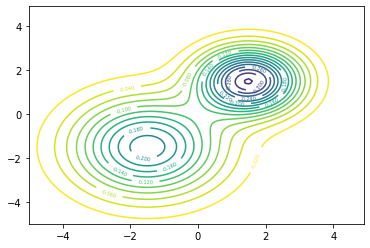


PART B


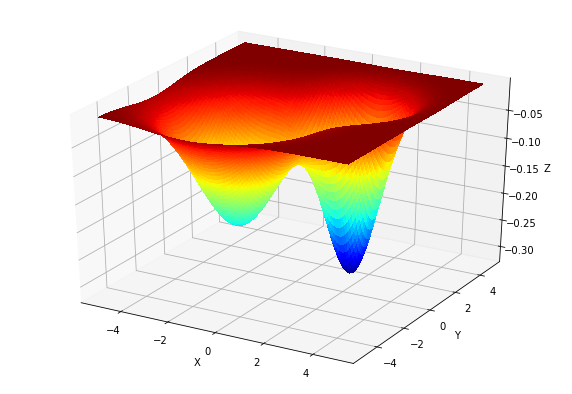


PART C
The activation barrier for the chemical reaction is: 0.2
This is not very accurate becuase the contour lines only have a definition of 0.02

PART D
Without using the countour plot, I calculated an activation energy of 0.211
This is more accurate because I calculated the lowest ridge with an accuracy of 0.0001.The saddle point that I found has the coordinates (x,y,z) = 0.011 0.011 -0.112


In [11]:
print('PART A')
#define the space
xmin=-5
xmax=5
dx=0.1
x=np.arange(xmin,xmax,dx)

ymin=-5
ymax=5
dy=0.1
y=np.arange(ymin,ymax,dy)
#meshgrid step
X, Y = np.meshgrid(x,y)

#define 1 dimensional Gaussian 
def gauss1D(x,x0,s):
    anorm=1.0/(np.sqrt(2.0*np.pi)*s)
    return anorm*np.exp(-(x-x0)**2/(2.0*(s**2)))

#define 2 dimensional Gaussian 
def gauss2D(x,y,x0,y0,sx,sy,A):
    return A*gauss1D(x,x0,sx)*gauss1D(y,y0,sy)

#set values given in the problem statement
x01=1.5
sx1=1.0
y01=1.5
sy1=1.0
A1=-2.0
A2=-3.0
x02=-1.5
sx2=1.5
y02=-1.5
sy2=1.5
#generate 2D gaussians for well 1 and well 2
well1= gauss2D(X,Y,x01,y01,sx1,sy1,A1)
well2= gauss2D(X,Y,x02,y02,sx2,sy2,A2)
#put Gaussians together
two_wells=well1+well2
#contour lines
levels=np.arange(-0.36,0,0.02)
CS = plt.contour(X,Y,two_wells,levels)
plt.clabel(CS, inline=1, fontsize=5)
plt.show()
print()
print('PART B')
Nx=np.size(x)
Ny=np.size(y)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, two_wells, rstride=1, cstride=1, cmap=cm.jet, linewidth=0,
    antialiased=False)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
print()
print('PART C')
#find the deepest shared countour and overall deepest countour using the countour map
deepestshared = -0.10 # lowest ridge value from eyeballing contour plot
overalldeepest = -0.30 #lowest overall point from looking at contour plot
activationestimate = deepestshared-overalldeepest
print('The activation barrier for the chemical reaction is:',np.round(activationestimate,3))
print("This is not very accurate becuase the contour lines only have a definition of 0.02")
print() 
print("PART D")
#calculate the lowest point using min
lowestpoint = np.min(two_wells)
# ridge point would have to be along y=x line
#define x values from one center to the other
x=np.arange(-1.5,1.5,0.0001)
#only looks at values on y=x from one center to the other, which is what we want
well1xy= gauss2D(x,x,x01,y01,sx1,sy1,A1)
well2xy= gauss2D(x,x,x02,y02,sx2,sy2,A2)
#add the data together
two_wells_xy=well1xy+well2xy
#get maximum between the two centers, which is the lowest ridge
lowestridge=np.max(two_wells_xy)
arg=np.argmax(two_wells_xy)
#get a more accurate estimation of the activation energy
accurate_ae=lowestridge-lowestpoint
#find x and y of saddle point using arg and my value and the value of the step from np.arange above
saddlepoint=(-1.5+arg*0.0001)
print('Without using the countour plot, I calculated an activation energy of',np.round(accurate_ae,3))
print("This is more accurate because I calculated the lowest ridge with an accuracy of 0.0001.The saddle point that I found has the coordinates (x,y,z) =",np.round(saddlepoint,3),np.round(saddlepoint,3),np.round(lowestridge,3))

## Problem 3: Explore the Electrocardiogram

The electrocardiogram (EKG) represents cardiac activity from one point in time to the next. It can be viewed as a *time-voltage* 1D signal of the heartbeat. The EKG provides critical information for clinical diagnosis of heart conditions. When looking at an EKG, doctors make certain measurements such as, heights of peaks, and areas under a curve.

You are given the EKG values of a 45 year old male in the file `AM10_cardio.txt`. This is an array containing the $y$ axis points (voltages in $mV$) of the signal. The $x$ points is the time in ($ms$) starting at $0$ and moving by $1ms$ for every data point.

The $𝑃𝑅$ segment is supposed to be on the $y=0$ horizontal line which is called the "baseline".
<BR><BR>
<img src='cardio.png' alt="Drawing" style="width: 400px;"/>
<BR><BR>
You are also given the two time points for the $QRS$ interval (marked by $QRS$ in the image above):

- `QRSWAVE_low`, the onset (starting time in $ms$ from the start of the signal) of the QRS wave, and 
- `QRSWAVE_high`, the ending time  of the QRS wave.

QRSWAVE_low = 460
QRSWAVE_high = 600

**1.** Load the file with the signal into a local variable. Plot the signal. 

**2.** We want the bulk of it to be along the $y=0$ horizontal axis, but as you will observe, our signal appears shifted. Move the signal along the $y$ axis so the $PR$ segment, the "baseline", is on $y=0$. This is also the position along which most of the signal is on the $y=0$ line.

**3.** The signal is too noisy as you can see. Use the `gaussian_filter1d` function (which has been imported by calling the statement 
```
from scipy.ndimage.filters import gaussian_filter1d
```
in the initial cell of this Notebook) to fit a set of gaussians on the signal and save the new smoothed signal, which you will use from now on.

**4.** Measure the height in $mV$ of the highest peak (the R peak). 

**5.** Measure the time interval from the onset of $QRS$ to the peak of $R$.

**6.** Calculate the 1/2 area under the $R$ curve (marked with purple in Fig.1). The start of the R interval is where the signal passes through the baseline before it starts its ascend to the $R$ peak.

<BR><BR>
<img src='QRS_area.png' alt="QRS" style="width: 400px;"/>
**Fig. 1**

**Note:** all voltage measurements are in respect to the "baseline" and all time measurements are from the start of the signal.

PART 1


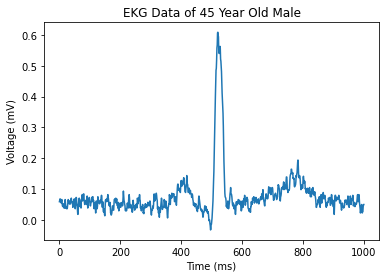

PART 2
The current baseline is y = 0.05 since the mode of the cardio data = [0.05]


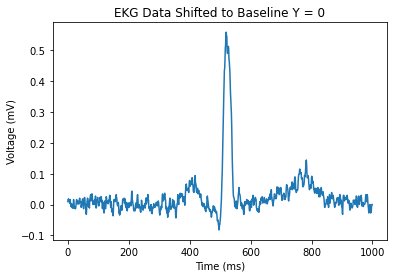

PART 3


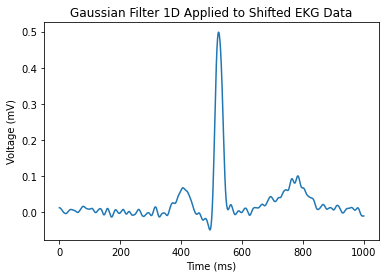


PART 4
The highest peak (R peak) is 0.498 mV

PART 5
The time interval from the onset of QRS to the peak of R is 62 ms

PART 6
Number of Roots in Interval of Interest = 1
Brackets:
503 504
My approximate root is: [503]
Half of the area under the R curve = 5.9


In [15]:
print('PART 1')
#load data
cardiodata=np.loadtxt('AM10_cardio.txt')
plt.plot(cardiodata)
plt.xlabel('Time (ms)')
plt.ylabel("Voltage (mV)")
plt.title("EKG Data of 45 Year Old Male")
plt.show()
print('PART 2')
#find where the most data points are occuring to calculate baseline
mode, occurences = stats.mode(cardiodata)
baseline = mode[0] # get rid of brackets for formatting purposes 
print("The current baseline is y =",baseline,"since the mode of the cardio data =", mode)
#shift the current baseline to y=0
shiftedcardio=cardiodata-baseline
#plot new graph with baseline at y=0
plt.plot(shiftedcardio)
plt.title("EKG Data Shifted to Baseline Y = 0")
plt.xlabel('Time (ms)')
plt.ylabel("Voltage (mV)")
plt.show()

print('PART 3')
#smooth the signal with sigma=5 
smoothsignal=gaussian_filter1d(shiftedcardio,5)
plt.plot(smoothsignal)
plt.title('Gaussian Filter 1D Applied to Shifted EKG Data')
plt.xlabel('Time (ms)')
plt.ylabel("Voltage (mV)")
plt.show()
print()
print('PART 4')
print("The highest peak (R peak) is",np.round(max(smoothsignal),3),"mV") #get overall max value using
print()
print('PART 5')
QRSWAVE_low = 460
#use argmax to get index of where the signal peaks, then subtract the index where QRS wave low starts
interval = np.argmax(smoothsignal)-QRSWAVE_low
print("The time interval from the onset of QRS to the peak of R is",interval,"ms")
print()
print('PART 6')
#find the index of the min point of the entire data set to guage where left bound should be for bracketing
absminindex=np.argmin(smoothsignal)
# find the appropriate root using bracketing method between absminindex and right bound, guessed 505 from graph
def bracketing_method(x, fx):
    nr = 0  # initialize number of roots
    xa = []  # initialize list to hold left brackets
    xb = []  # initialize list to hold right brackets
    for i in range(len(x) - 1):  # run loop for all elements of x but last 
        fprod = fx[i] * fx[i+1]  
        if fprod < 0:  # check sign for zero-crossing
            xa.append(x[i])
            xb.append(x[i+1])
            nr = nr + 1
    print('Number of Roots in Interval of Interest =', nr)
    print('Brackets:')
    for i in range(nr):
        print(xa[i], xb[i])
    return xa, xb, nr
interval_of_interest=np.arange(absminindex,505,1) #generate interval to look for the root that we want!
left,right,numroots=bracketing_method(interval_of_interest,shiftedcardio)
# define simpson integration
def simpnv(f, xmin, xmax):
     # Find Nx and Dx
    
    Nx= xmax - xmin
    Dx = 1
    
    
    sum1 = 0.0
    sum2 = 0.0
    
     #Compute the sums for even and odd terms
    
    for n in range(xmin, xmax):
        if n % 2 == 1:    # check n is odd and compute sum1
             sum1 += f[n]  # This is the same as sum1 = sum1 + f[n]
        if n % 2 == 0:    # check n is even and compute sum2 
             sum2 += f[n]  
    
    Ints = (1.0 / 3.0) * Dx * (f[xmin] + 4.0 * sum1 + 2.0 * sum2 + f[xmax])
    
    return Ints
print("My approximate root is:",left)
halfarea=simpnv(smoothsignal,503,np.argmax(smoothsignal)) #integrate from approx root (index 503) to peak (index 522)
print("Half of the area under the R curve =",np.round(halfarea,1))
